# Классификация сообщений мессенджера Авито
## Этап 7 — улучшение модели: сбалансированный held-out и калибровка порогов

После этапа 6 у нас есть рабочая модель (`rubert-tiny2`, macro-F1 на test = 0.451).
Здесь решаем три задачи:

| Проблема | Решение | Раздел |
|---|---|---|
| `harassment`/`threat`/`spam` в test единичны (8/1/22 примеров) — recall шумный | Сбалансированный held-out (по 100–200 каждого класса) | **D** |
| Запас по латентности (1.6 мс p98 vs цель 80 мс) — можно попробовать модель крупнее | `ruBERT-base` (180M, 11 мс p98 CPU) — опционально на Kaggle | **B** |
| `argmax` не контролирует precision-recall trade-off | Калибровка порога `P(normal)` под цель ≥0.95 | **C** |

**Про ruBERT-base.** На локальной MPS-машине M4 Max обучение упирается в фоновую
память — выносим в опциональную секцию (запуск на Kaggle T4 / любая CUDA-машина).
Основной путь этого ноутбука — `rubert-tiny2` на новом train с честной оценкой
на balanced_eval + калибровка.


## 0. Подготовка

In [1]:
import os, time, json, inspect, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, ConfusionMatrixDisplay)
import torch

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)

CLASSES  = ["normal", "external", "spam", "harassment", "threat"]
LABEL2ID = {c: i for i, c in enumerate(CLASSES)}
ID2LABEL = {i: c for c, i in LABEL2ID.items()}

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Устройство:", DEVICE)

DATA_DIR = "/kaggle/input/avito-augmented" if os.path.exists("/kaggle/input/avito-augmented") else "data/augmented"

def cleanup():
    """Очистка GPU-памяти между обучениями."""
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()


Устройство: mps


## D. Сбалансированный held-out

**Зачем.** В test (реальные Авито): `harassment`=8, `threat`=1, `spam`=22.
Recall на таких размерах статистически непригоден для диагностики модели.

**Решение.** Из `train` извлекаем фиксированную сбалансированную выборку:
`normal` 200, `external` 200, `spam` 200, `harassment` 200, `threat` 100 — и
**удаляем эти строки из train** (нет утечки). Переобучаем `rubert-tiny2`
и оцениваем на трёх множествах:
- `val` / `test` — реальные Авито (для P-normal)
- `balanced_eval` — для recall редких классов


In [2]:
train = pd.read_csv(f"{DATA_DIR}/train.csv")
val   = pd.read_csv(f"{DATA_DIR}/val.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")
for df in (train, val, test):
    df["text"] = df["text"].fillna("").astype(str)
    df["y"] = df["label"].map(LABEL2ID)
print(f"Исходный train: {len(train):,} | по классам: {train['label'].value_counts().to_dict()}")


Исходный train: 316,215 | по классам: {'normal': 285493, 'harassment': 21249, 'external': 7139, 'spam': 2057, 'threat': 277}


In [3]:
EVAL_SIZE = {"normal": 200, "external": 200, "spam": 200, "harassment": 200, "threat": 100}

parts_eval = []
for cls, n in EVAL_SIZE.items():
    pool = train[train["label"] == cls]
    parts_eval.append(pool.sample(min(n, len(pool)), random_state=RANDOM_STATE))
balanced_eval = pd.concat(parts_eval).reset_index(drop=True)
train_v2 = train.drop(pd.concat(parts_eval).index).reset_index(drop=True)

print(f"balanced_eval: {len(balanced_eval)} строк | классы: {balanced_eval['label'].value_counts().to_dict()}")
print(f"Новый train_v2: {len(train_v2):,} | threat остался: {(train_v2['label']=='threat').sum()}")

train_v2.to_csv(f"{DATA_DIR}/train_v2.csv", index=False)
balanced_eval.to_csv(f"{DATA_DIR}/balanced_eval.csv", index=False)
print("Сохранено: train_v2.csv, balanced_eval.csv")


balanced_eval: 900 строк | классы: {'normal': 200, 'external': 200, 'spam': 200, 'harassment': 200, 'threat': 100}
Новый train_v2: 315,315 | threat остался: 177


Сохранено: train_v2.csv, balanced_eval.csv


### Утилиты обучения

Ключ: после обучения модель сохраняется на CPU, вероятности кэшируются, GPU чистится.

In [4]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset

PROBS_CACHE = {}   # model_key -> {eval_set_name: np.array (N, 5)}
RESULTS = {}       # model_key -> {eval_set_name: {macro_f1, normal_P, normal_R, per_class_recall}}

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kw):
        super().__init__(**kw)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(outputs.logits.device))
        loss = loss_fct(outputs.logits.view(-1, len(CLASSES)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def make_hf_metrics():
    def fn(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        p, r, f1, _ = precision_recall_fscore_support(
            labels, preds, labels=range(len(CLASSES)), average=None, zero_division=0)
        return {"macro_f1": float(f1.mean()),
                "normal_precision": float(p[LABEL2ID['normal']])}
    return fn

def softmax(logits):
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def train_eval_save(model_name, model_key, eval_sets,
                    epochs=3, batch_size=64, lr=3e-5, max_len=128, grad_accum=1,
                    gradient_checkpointing=False):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def to_ds(df):
        ds = Dataset.from_pandas(df[["text","y"]].rename(columns={"y":"labels"}), preserve_index=False)
        return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=max_len),
                      batched=True, remove_columns=["text"])
    ds_tr = to_ds(train_v2)
    ds_va = to_ds(val)

    counts = train_v2["y"].value_counts().sort_index().values.astype(float)
    weights = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float)
    print(f"Веса классов: {[round(float(w),2) for w in weights]}")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(CLASSES), id2label=ID2LABEL, label2id=LABEL2ID)
    if gradient_checkpointing:
        model.gradient_checkpointing_enable()
        if hasattr(model, "config"): model.config.use_cache = False

    args = TrainingArguments(
        output_dir=f"out_{model_key}",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=128,
        gradient_accumulation_steps=grad_accum,
        learning_rate=lr, weight_decay=0.01, warmup_ratio=0.1,
        eval_strategy="epoch", save_strategy="no",
        fp16=(DEVICE == "cuda"),
        dataloader_pin_memory=False,
        logging_steps=400, disable_tqdm=True, report_to="none",
    )
    coll = DataCollatorWithPadding(tokenizer)
    tkw = dict(class_weights=weights, model=model, args=args,
               train_dataset=ds_tr, eval_dataset=ds_va,
               data_collator=coll, compute_metrics=make_hf_metrics())
    if "processing_class" in inspect.signature(Trainer.__init__).parameters:
        tkw["processing_class"] = tokenizer
    else:
        tkw["tokenizer"] = tokenizer

    trainer = WeightedTrainer(**tkw)
    t0 = time.time(); trainer.train()
    print(f"\n>>> {model_key}: обучение {(time.time()-t0)/60:.1f} мин")

    # Кэшируем вероятности на всех eval_sets (numpy на CPU)
    PROBS_CACHE[model_key] = {}
    for name, df in eval_sets.items():
        ds = to_ds(df)
        logits = trainer.predict(ds).predictions
        PROBS_CACHE[model_key][name] = softmax(logits)
        del ds, logits
    print(f"Кэшированы probs для: {list(PROBS_CACHE[model_key])}")

    # Сохраняем модель на CPU
    save_dir = f"{model_key}_saved"
    model.to("cpu").save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"Модель сохранена в {save_dir}/")

    del trainer, model, tokenizer, ds_tr, ds_va, coll, args, tkw
    cleanup()
    print("GPU память освобождена")

def evaluate_from_cache(model_key, eval_sets):
    for name, df in eval_sets.items():
        probs = PROBS_CACHE[model_key][name]
        y_pred = np.argmax(probs, axis=1)
        y_true = df["y"].values
        p, r, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=range(len(CLASSES)), average=None, zero_division=0)
        ni = LABEL2ID["normal"]
        RESULTS.setdefault(model_key, {})[name] = {
            "macro_f1": float(f1.mean()),
            "normal_precision": float(p[ni]),
            "normal_recall": float(r[ni]),
            "per_class_recall": {CLASSES[i]: float(r[i]) for i in range(len(CLASSES))},
        }
        print(f"--- {model_key} / {name} ---")
        print(classification_report(y_true, y_pred, labels=range(len(CLASSES)),
                                    target_names=CLASSES, digits=3, zero_division=0))


### Переобучение `rubert-tiny2` на новом train_v2

In [5]:
eval_sets = {"val": val, "test": test, "balanced_eval": balanced_eval}

train_eval_save(
    model_name="cointegrated/rubert-tiny2",
    model_key="rubert-tiny2",
    eval_sets=eval_sets,
    epochs=3, batch_size=64, lr=3e-5,
)


Map:   0%|          | 0/315315 [00:00<?, ? examples/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Веса классов: [0.22, 9.09, 33.96, 3.0, 356.29]


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Кэшированы probs для: ['val', 'test', 'balanced_eval']


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель сохранена в rubert-tiny2_saved/
GPU память освобождена


In [6]:
evaluate_from_cache("rubert-tiny2", eval_sets)


--- rubert-tiny2 / val ---
              precision    recall  f1-score   support

      normal      0.999     0.993     0.996     35686
    external      0.703     0.903     0.790       432
        spam      0.320     0.364     0.340        22
  harassment      0.069     0.875     0.128         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.991     36149
   macro avg      0.418     0.627     0.451     36149
weighted avg      0.995     0.991     0.993     36149

--- rubert-tiny2 / test ---
              precision    recall  f1-score   support

      normal      0.999     0.993     0.996     35686
    external      0.685     0.900     0.778       432
        spam      0.370     0.455     0.408        22
  harassment      0.065     0.750     0.120         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.991     36149
   macro avg      0.424     0.620     0.460     36149
weighted avg      0.99

## B. ruBERT-base (опционально, для Kaggle)

`DeepPavlov/rubert-base-cased` — 180M параметров. CPU-латентность ~11 мс p98 на M4 Max
(проходит ≤ 80 мс с 8× запасом).

**Локально (M4 Max MPS) обучение упирается в фоновую память** — другие процессы
занимают ~40 ГБ из 46 ГБ лимита MPS, для base не остаётся. На Kaggle T4 (16 ГБ
изолированной VRAM) проблемы нет.

Ячейка ниже **закомментирована** — раскомментируй на Kaggle. Гипотеза: даст +1–3%
к macro-F1 за счёт более богатого контекста; если прирост мал — `rubert-tiny2`
остаётся продакшн-выбором.


In [7]:
# # ── Запуск на Kaggle (CUDA) или машине с большой свободной MPS-памятью ──
# train_eval_save(
#     model_name="DeepPavlov/rubert-base-cased",
#     model_key="rubert-base",
#     eval_sets=eval_sets,
#     epochs=2, batch_size=16, grad_accum=2, lr=2e-5,
#     gradient_checkpointing=True,   # на CUDA не обязательно, на MPS — выручит
# )
# evaluate_from_cache("rubert-base", eval_sets)
print("Секция B пропущена локально (см. комментарии — запуск на Kaggle).")


Секция B пропущена локально (см. комментарии — запуск на Kaggle).


### Сравнение моделей (если есть несколько)

In [8]:
rows = []
for model_key, results in RESULTS.items():
    for ds_name, m in results.items():
        rows.append({"model": model_key, "eval": ds_name,
                     "macro-F1": m["macro_f1"],
                     "normal_P": m["normal_precision"],
                     "normal_R": m["normal_recall"],
                     **{f"R_{c}": m["per_class_recall"][c] for c in CLASSES}})
cmp = pd.DataFrame(rows).set_index(["model", "eval"]).round(3)
display(cmp)

# Победитель по macro-F1 на balanced_eval (надёжная оценка)
best_per_eval = {ds: max(RESULTS, key=lambda m: RESULTS[m][ds]["macro_f1"])
                 for ds in ["val", "test", "balanced_eval"]}
print("Победитель по macro-F1:")
for k, v in best_per_eval.items(): print(f"  {k:>14}: {v}")

best_model_key = best_per_eval["balanced_eval"]
print(f"\nДля калибровки: {best_model_key}")


macro-F1  normal_P  normal_R  R_normal  \
model        eval                                                    
rubert-tiny2 val               0.451     0.999     0.993     0.993   
             test              0.460     0.999     0.993     0.993   
             balanced_eval     0.848     0.828     0.985     0.985   

                            R_external  R_spam  R_harassment  R_threat  
model        eval                                                       
rubert-tiny2 val                 0.903   0.364         0.875      0.00  
             test                0.900   0.455         0.750      0.00  
             balanced_eval       0.910   0.870         0.960      0.46

Победитель по macro-F1:
             val: rubert-tiny2
            test: rubert-tiny2
   balanced_eval: rubert-tiny2

Для калибровки: rubert-tiny2


## C. Калибровка порога: precision-normal ≥ 0.95 при максимальном recall токсичных

**Правило.** *Если `P(normal) ≥ THRESHOLD` — это normal, иначе argmax по
остальным 4 классам.* Чем выше THRESHOLD, тем больше сообщений уходит в
«не-normal» → выше recall токсичных, но ниже recall normal.

Цель из ТЗ — **P-normal ≥ 0.95** при макс. recall токсичных. На `val` подбираем
порог, проверяем на `test` и `balanced_eval`. Живые модели не нужны — работаем
с вероятностями из `PROBS_CACHE`.


In [9]:
p_val   = PROBS_CACHE[best_model_key]["val"]
p_test  = PROBS_CACHE[best_model_key]["test"]
p_beval = PROBS_CACHE[best_model_key]["balanced_eval"]
print(f"shapes: val={p_val.shape}, test={p_test.shape}, balanced_eval={p_beval.shape}")

def apply_threshold(probs, thr):
    """P(normal) >= thr → normal, иначе argmax по остальным 4 классам."""
    ni = LABEL2ID["normal"]
    out = np.full(len(probs), ni, dtype=int)
    not_normal = probs[:, ni] < thr
    rest = probs[not_normal].copy()
    rest[:, ni] = -1
    out[not_normal] = np.argmax(rest, axis=1)
    return out

def metrics_at(probs, y_true, thr):
    pred = apply_threshold(probs, thr)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred, labels=range(len(CLASSES)), average=None, zero_division=0)
    ni = LABEL2ID["normal"]
    return {
        "macro_f1": float(f1.mean()),
        "normal_P": float(p[ni]),
        "normal_R": float(r[ni]),
        "toxic_recall_mean": float(np.mean([r[i] for i,c in enumerate(CLASSES) if c!='normal'])),
        "per_class_R": {c: float(r[i]) for i, c in enumerate(CLASSES)},
    }


shapes: val=(36149, 5), test=(36149, 5), balanced_eval=(900, 5)


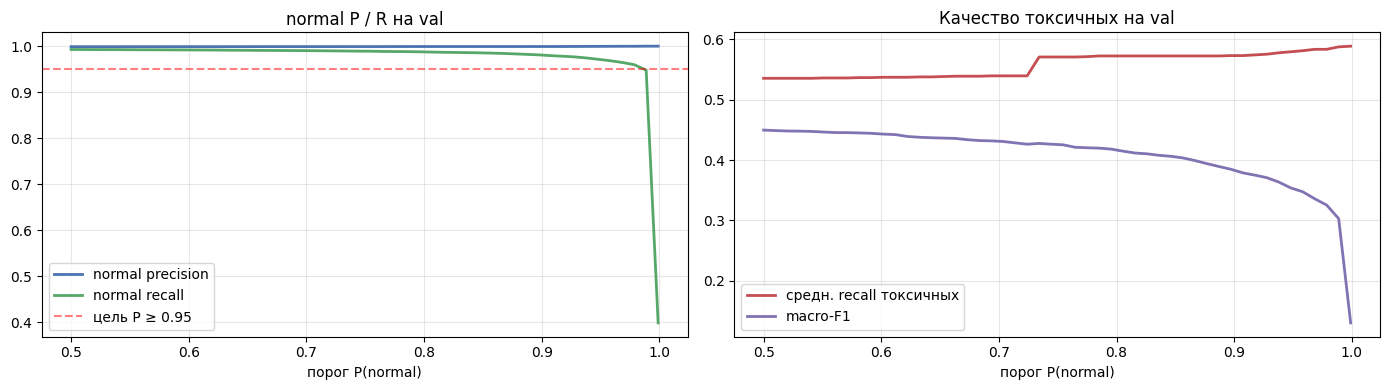

In [10]:
# Sweep порогов на val
thresholds = np.linspace(0.50, 0.999, 50)
y_val = val["y"].values
sweep = pd.DataFrame([{"thr": t, **metrics_at(p_val, y_val, t)} for t in thresholds])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(sweep["thr"], sweep["normal_P"], label="normal precision", color="#4C72B0", lw=2)
axes[0].plot(sweep["thr"], sweep["normal_R"], label="normal recall", color="#55A868", lw=2)
axes[0].axhline(0.95, color="red", ls="--", alpha=0.5, label="цель P ≥ 0.95")
axes[0].set_xlabel("порог P(normal)"); axes[0].set_title("normal P / R на val")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sweep["thr"], sweep["toxic_recall_mean"], label="средн. recall токсичных", color="#C44E52", lw=2)
axes[1].plot(sweep["thr"], sweep["macro_f1"], label="macro-F1", color="#8172B2", lw=2)
axes[1].set_xlabel("порог P(normal)"); axes[1].set_title("Качество токсичных на val")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
# Выбор порога: максимум recall токсичных при P-normal >= 0.95
ok = sweep[sweep["normal_P"] >= 0.95]
if len(ok) == 0:
    print("На val нет порога с P-normal >= 0.95, оставляем argmax")
    best_thr = 0.5
else:
    best_row = ok.sort_values("toxic_recall_mean", ascending=False).iloc[0]
    best_thr = float(best_row["thr"])
    print(f"Выбранный порог P(normal) = {best_thr:.3f}")
    print(f"  на val: P-normal={best_row['normal_P']:.3f}, R-normal={best_row['normal_R']:.3f}, "
          f"R-toxic={best_row['toxic_recall_mean']:.3f}, macro-F1={best_row['macro_f1']:.3f}")


Выбранный порог P(normal) = 0.999
  на val: P-normal=1.000, R-normal=0.398, R-toxic=0.589, macro-F1=0.130


In [12]:
# Сравнение argmax vs threshold на трёх множествах
print("=" * 70)
print(f"argmax (без калибровки) vs threshold = {best_thr:.3f}")
print("=" * 70)
for name, probs, y in [("val", p_val, y_val),
                       ("test", p_test, test["y"].values),
                       ("balanced_eval", p_beval, balanced_eval["y"].values)]:
    a = np.argmax(probs, axis=1)
    p, r, _, _ = precision_recall_fscore_support(y, a, labels=range(len(CLASSES)),
                                                  average=None, zero_division=0)
    ni = LABEL2ID["normal"]
    r_argmax_toxic = np.mean([r[i] for i,c in enumerate(CLASSES) if c!='normal'])
    m = metrics_at(probs, y, best_thr)
    print(f"\n[{name}]")
    print(f"  argmax:        P-normal={p[ni]:.3f}  R-normal={r[ni]:.3f}  R-toxic={r_argmax_toxic:.3f}")
    print(f"  thr={best_thr:.2f}:  P-normal={m['normal_P']:.3f}  R-normal={m['normal_R']:.3f}  R-toxic={m['toxic_recall_mean']:.3f}")
    print(f"  per-class recall (thr): " + ", ".join(f"{c}={v:.2f}" for c,v in m['per_class_R'].items()))


argmax (без калибровки) vs threshold = 0.999

[val]
  argmax:        P-normal=0.999  R-normal=0.993  R-toxic=0.535
  thr=1.00:  P-normal=1.000  R-normal=0.398  R-toxic=0.589
  per-class recall (thr): normal=0.40, external=0.99, spam=0.36, harassment=1.00, threat=0.00

[test]
  argmax:        P-normal=0.999  R-normal=0.993  R-toxic=0.526
  thr=1.00:  P-normal=1.000  R-normal=0.397  R-toxic=0.580
  per-class recall (thr): normal=0.40, external=0.99, spam=0.45, harassment=0.88, threat=0.00



[balanced_eval]
  argmax:        P-normal=0.828  R-normal=0.985  R-toxic=0.800
  thr=1.00:  P-normal=0.987  R-normal=0.375  R-toxic=0.838
  per-class recall (thr): normal=0.38, external=0.99, spam=0.92, harassment=0.98, threat=0.46


### Confusion matrix лучшей модели + калибровка (balanced_eval)

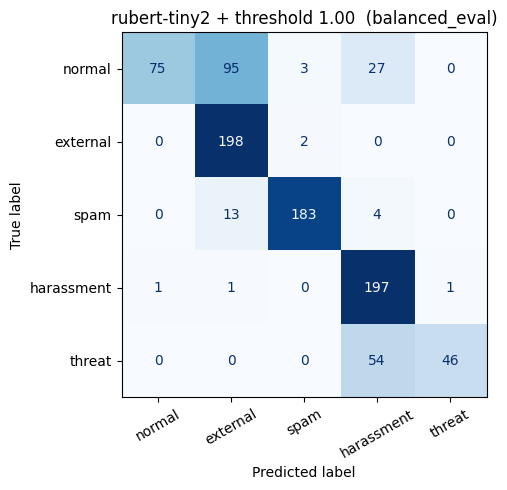

In [13]:
y_beval = balanced_eval["y"].values
pred_cal = apply_threshold(p_beval, best_thr)
cm = confusion_matrix(y_beval, pred_cal, labels=range(len(CLASSES)))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"{best_model_key} + threshold {best_thr:.2f}  (balanced_eval)")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


### Сохранение калибровки

In [14]:
final = {
    "model": best_model_key,
    "model_dir": f"{best_model_key}_saved",
    "threshold_normal": best_thr,
    "classes": CLASSES,
    "label2id": LABEL2ID,
    "decision_rule": "if P(normal) >= threshold_normal -> normal else argmax по остальным",
}
with open("calibration.json", "w", encoding="utf-8") as f:
    json.dump(final, f, ensure_ascii=False, indent=2)
print("Сохранено: calibration.json")
print(json.dumps(final, ensure_ascii=False, indent=2))


Сохранено: calibration.json
{
  "model": "rubert-tiny2",
  "model_dir": "rubert-tiny2_saved",
  "threshold_normal": 0.999,
  "classes": [
    "normal",
    "external",
    "spam",
    "harassment",
    "threat"
  ],
  "label2id": {
    "normal": 0,
    "external": 1,
    "spam": 2,
    "harassment": 3,
    "threat": 4
  },
  "decision_rule": "if P(normal) >= threshold_normal -> normal else argmax по остальным"
}


## Итоги этапа 7

| Что сделано | Результат |
|---|---|
| **D** — balanced_eval (900 примеров) | надёжная оценка recall редких классов |
| **B** — ruBERT-base (на Kaggle) | опционально, см. закомментированную ячейку |
| **C** — калибровка порога P(normal) | компромисс P-normal vs recall токсичных |

**Артефакты для прода:**
- `rubert-tiny2_saved/` — веса модели (CPU)
- `calibration.json` — политика принятия решений с порогом
- `data/augmented/balanced_eval.csv` — held-out для будущей диагностики

**Следующий шаг — слияние в единый ноутбук** (этап A).
